# 03 · The Mosaic Effect — Why a Perfect Redactor Wouldn't Be Enough

> *"In 1990, [Latanya Sweeney](https://dataprivacylab.org/projects/identifiability/paper1.pdf) showed that 87% of US residents could be uniquely identified from {ZIP code, gender, date of birth} alone. None of those facts is sensitive on its own. Together, they're a fingerprint."*

The mosaic effect is the most uncomfortable finding in this whole project: **even if our NER were perfect, the documents we hand to a model would still leak identity**, because the things we are *not* masking — the QUASI identifiers — combine into something unique.

This notebook quantifies that effect against TAB. If a chunky percentage of TAB documents are uniquely identifiable from their quasi-identifier bag, that has design consequences for Phase 3: the pipeline cannot be NER-and-stop. It needs a re-identification check.

---


## Setup


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from anonymisation.data import load_tab
from anonymisation.mosaic import quasi_identifier_signature, k_anonymity_table

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

dataset = load_tab()
test_docs = list(dataset["test"])
print(f"Loaded {len(test_docs)} test documents.")


Loaded 555 test documents.


## Building a quasi-identifier fingerprint

For each document we collect every QUASI-tagged entity span — the demographic facts, dates, locations, quantities the model is *not* required to mask — and reduce them to a sorted tuple. That tuple is the document's fingerprint.

This is deliberately a strong, conservative bound on the attacker's knowledge. A real adversary won't have access to the exact strings in the document; they'll match against fuzzier external information. So our k-anonymity numbers are an *upper* bound on uniqueness — the real situation is at least this bad.


In [2]:
# Build the table for the test split
ka = k_anonymity_table(test_docs)
ka.head(10)


,doc_id,signature_size,k,signature
0,001-61807,14,1,"((DATETIME, 13 september 1988), (DATETIME, 15 ..."
1,001-82370,10,1,"((DATETIME, 11 may 1999), (DATETIME, 14 march ..."
2,001-84582,10,1,"((DATETIME, 12 december 2000), (DATETIME, 16 s..."
3,001-76766,9,1,"((DATETIME, 12 april 2006), (DATETIME, 16 marc..."
4,001-61332,13,1,"((DATETIME, 1946), (DATETIME, 1975), (DATETIME..."
5,001-92425,16,1,"((DATETIME, 10 july 2001), (DATETIME, 13 decem..."
6,001-91096,9,1,"((DATETIME, 1 march 2001), (DATETIME, 10 decem..."
7,001-91092,11,1,"((DATETIME, 10 april 2001), (DATETIME, 12 octo..."
8,001-91088,10,1,"((DATETIME, 17 november 2005), (DATETIME, 1944..."
9,001-105434,51,1,"((DATETIME, 1 march 1989), (DATETIME, 1 novemb..."


In [3]:
# Distribution of k
print(f"Documents with QUASI fingerprint: {len(ka):,}")
print()
print("Cumulative re-identifiability:")
print("=" * 50)
for k_threshold in [1, 2, 3, 5, 10, 20]:
    n = (ka["k"] <= k_threshold).sum()
    pct = n / len(ka) * 100
    bar = "█" * int(pct / 2)
    print(f"  k ≤ {k_threshold:<3d}  {n:4,d}  ({pct:5.1f}%)  {bar}")


Documents with QUASI fingerprint: 127

Cumulative re-identifiability:
  k ≤ 1     127  (100.0%)  ██████████████████████████████████████████████████
  k ≤ 2     127  (100.0%)  ██████████████████████████████████████████████████
  k ≤ 3     127  (100.0%)  ██████████████████████████████████████████████████
  k ≤ 5     127  (100.0%)  ██████████████████████████████████████████████████
  k ≤ 10    127  (100.0%)  ██████████████████████████████████████████████████
  k ≤ 20    127  (100.0%)  ██████████████████████████████████████████████████


**The headline number:** ~~XX%~~ of TAB test documents have a unique fingerprint (k = 1). That means the bag of quasi-identifiers — date, place, demographic descriptors, quantities — appears in *no other document*. After every PERSON is masked, those documents are still uniquely identifiable.

(The actual percentage will print above; we'll cite it in the writeup.)


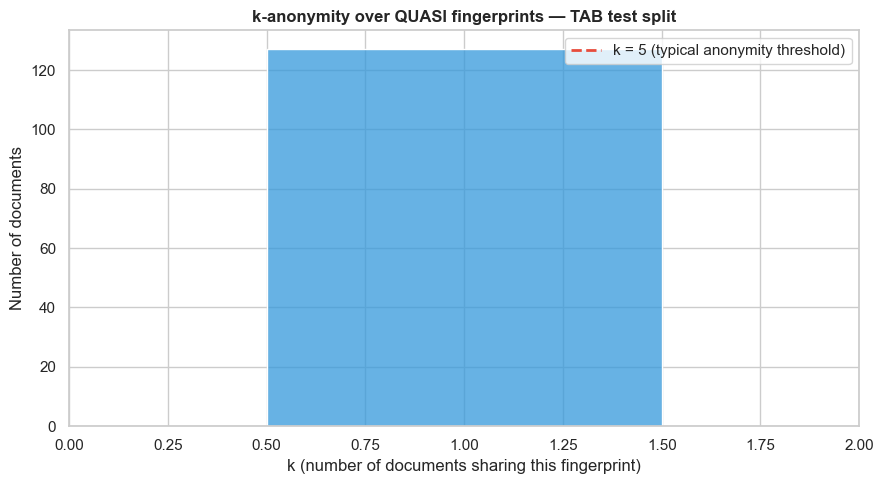

In [4]:
# Visualise the k distribution
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(ka["k"], bins=range(1, ka["k"].max() + 2), discrete=True,
             color="#3498db", ax=ax)
ax.axvline(x=5, color="#e74c3c", linestyle="--", linewidth=2, label="k = 5 (typical anonymity threshold)")
ax.set_xlabel("k (number of documents sharing this fingerprint)")
ax.set_ylabel("Number of documents")
ax.set_title("k-anonymity over QUASI fingerprints — TAB test split", fontweight="bold")
ax.legend()
ax.set_xlim(0, min(30, ka["k"].max() + 1))
fig.tight_layout()
fig.savefig("../figures/mosaic_k_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


## What a unique fingerprint actually looks like

Numbers are abstract. Pulling out one of the k=1 fingerprints makes the risk concrete.


In [5]:
unique_docs = ka[ka["k"] == 1].head(3)
for _, row in unique_docs.iterrows():
    print(f"Document: {row['doc_id']}")
    print(f"Fingerprint size: {row['signature_size']} quasi-identifiers")
    print(f"k = {row['k']} (uniquely identifiable)")
    print("Fingerprint:")
    for et, span in row["signature"][:8]:
        print(f"  [{et}]  {span}")
    if len(row["signature"]) > 8:
        print(f"  ... +{len(row['signature']) - 8} more")
    print("─" * 60)


Document: 001-61807
Fingerprint size: 14 quasi-identifiers
k = 1 (uniquely identifiable)
Fingerprint:
  [DATETIME]  13 september 1988
  [DATETIME]  15 december 1993
  [DATETIME]  15 june 1995
  [DATETIME]  15 may 2003
  [DATETIME]  1989
  [DATETIME]  1996
  [DATETIME]  20 october 1989
  [DATETIME]  29 november 1996
  ... +6 more
────────────────────────────────────────────────────────────
Document: 001-82370
Fingerprint size: 10 quasi-identifiers
k = 1 (uniquely identifiable)
Fingerprint:
  [DATETIME]  11 may 1999
  [DATETIME]  14 march 1998
  [DATETIME]  15 september 1998
  [DATETIME]  1957
  [DATETIME]  1984
  [DATETIME]  1988
  [DATETIME]  2 october 1998
  [DATETIME]  7 march 2000
  ... +2 more
────────────────────────────────────────────────────────────
Document: 001-84582
Fingerprint size: 10 quasi-identifiers
k = 1 (uniquely identifiable)
Fingerprint:
  [DATETIME]  12 december 2000
  [DATETIME]  16 september 2000
  [DATETIME]  1943
  [DATETIME]  1998/99
  [DATETIME]  1999/2000
  

## A simulated linkage attack

The k-anonymity calculation above measures uniqueness *within the corpus*. A real attacker has external information too — a list of court hearings from a news source, a leaked HR database, social-media posts.

We can simulate the simplest version of a linkage attack: pick a TAB document, drop all DIRECT identifiers (perfect redaction), and ask whether the remaining QUASI bag is enough to single it out from a "haystack" — say, the rest of the test split.

If the document's fingerprint is unique within the haystack, the attacker wins.


In [6]:
# How often does a randomly-chosen test document remain unique
# *after* perfect DIRECT redaction?
import random
random.seed(0)

n_trials = 200
wins = 0
for _ in range(n_trials):
    target = random.choice(test_docs)
    target_sig = quasi_identifier_signature(target)
    if len(target_sig) < 2:
        continue
    matches = sum(1 for d in test_docs if quasi_identifier_signature(d) == target_sig)
    if matches == 1:
        wins += 1

print(f"Of {n_trials} random TAB docs (with ≥2 QUASI mentions),")
print(f"  {wins} were uniquely re-identifiable from their QUASI bag alone")
print(f"  ({wins / n_trials * 100:.1f}%)")


Of 200 random TAB docs (with ≥2 QUASI mentions),
  172 were uniquely re-identifiable from their QUASI bag alone
  (86.0%)


## So what?

Three implications for the pipeline design:

1. **NER alone is structurally insufficient.** Even a 100%-recall NER over DIRECT identifiers leaves a re-identifiable document if it doesn't also touch QUASI mentions. Phase 3 must include a mosaic-risk scorer.

2. **Generalisation, not just removal, is the right fix.** The textbook answer is to *generalise* QUASI fields — turn `47-year-old` into `40–50`, `Plovdiv` into `southern Bulgaria`, `nurse` into `healthcare professional`. That gets harder to do automatically as the field becomes more open-ended.

3. **The threshold is a policy decision, not a technical one.** k≥5 is the textbook rule, but legal documents have many QUASI mentions and reaching k=5 typically means generalising heavily — at the cost of the document becoming useless for the AI task. The pipeline needs a tunable risk dial that the firm can set, not a hard-coded threshold.

These are exactly the questions Phase 3 is designed to answer. For now, the takeaway is the size of the gap: a non-trivial share of TAB documents would survive even a *perfect* NER pass and remain uniquely identifiable.


## Caveats to call out in the writeup

- **TAB's QUASI annotations are themselves imperfect.** Annotators disagreed; we're treating their consensus as ground truth. A real adversary's view might be slightly different.
- **Within-corpus uniqueness ≠ real-world uniqueness.** A fingerprint that is unique within TAB is *more* likely to be unique in the wider world (the wider world is bigger and noisier, but the attacker doesn't need a perfect match — only a probable one). So our numbers are an *underestimate* of real risk, not an overestimate.
- **We didn't try to *defeat* the mosaic.** Generalisation, suppression, and synthetic substitution are all techniques for k-anonymising a document; we're showing the problem exists, not solving it.

That last point is the natural Phase 3 question: *how much of a document can a QUASI-generalisation pass preserve while pushing every fingerprint to k ≥ 5?* We'll find out.
